# ASL Sign Language Classification
### End-to-End Machine Learning Pipeline — From Raw Images to Production Inference

---

> **What this notebook builds:**  
> A complete pipeline that takes raw ASL hand-sign images, extracts compact 63-dimensional
> feature vectors via **Google MediaPipe** hand-landmark detection, trains and compares three
> classifiers (**KNN, SVM, Random Forest**), explains predictions with **SHAP**, and exports
> every artefact needed for real-time inference.

---

| Property | Detail |
|---|---|
| **Dataset** | Kaggle ASL Alphabet — 87,000 images, 29 classes |
| **Feature vector** | MediaPipe 21 hand landmarks x (x, y, z) = 63 floats |
| **Models** | KNN, SVM (RBF/Poly), Random Forest (300 trees) |
| **Tuning** | GridSearchCV with 5-fold stratified cross-validation |
| **Class balance** | SMOTE over-sampling |
| **Explainability** | SHAP TreeExplainer — per-landmark importance |
| **Outputs** | .pkl models + scaler + label encoder + metrics JSON |

---


## 1  Environment Setup & Dependencies

**Why this cell matters:**  
Google Colab ships with an older `mediapipe` that does **not** include the modern
`HandLandmarker` Tasks API we use in Section 4.  We force-reinstall it first, then
install every other library in one pass so the rest of the notebook runs cleanly.

> **Run once per session** — takes ~60 seconds on a standard Colab runtime.


In [ ]:
# ─── Cell 1: Package Installation ───────────────────────────────────────────
# PURPOSE:
#   Install and pin all Python dependencies this notebook needs.
#   mediapipe is uninstalled first because Colab's pre-installed version is
#   too old — it does not expose vision.HandLandmarker (Tasks API).
#
# WHAT EACH PACKAGE DOES:
#   mediapipe            — Google's hand-landmark detector (our feature extractor)
#   opencv-python-headless — Image loading/colour conversion (no display required)
#   scikit-learn         — KNN, SVM, Random Forest, GridSearchCV, metrics
#   matplotlib / seaborn — All visualisation
#   pandas               — SHAP importance dataframe
#   numpy                — Numerical arrays
#   joblib               — Fast model serialisation (memory-mapped .pkl files)
#   tqdm                 — Progress bars during feature extraction
#   kaggle               — CLI to download the dataset
#   shap                 — SHapley Additive exPlanations (model explainability)
#   imbalanced-learn     — SMOTE for class balancing
# ─────────────────────────────────────────────────────────────────────────────

import subprocess, sys

packages = [
    'mediapipe', 'opencv-python-headless', 'scikit-learn',
    'matplotlib', 'seaborn', 'pandas', 'numpy',
    'joblib', 'tqdm', 'kaggle', 'shap', 'imbalanced-learn'
]

for pkg in packages:
    if pkg == 'mediapipe':
        # Must reinstall fresh: Colab default lacks the Tasks API
        print(f'Uninstalling {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', pkg, '-y', '-q'])
        print(f'Installing/Upgrading {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--upgrade', '-q'])
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')


Uninstalling mediapipe...
Installing/Upgrading mediapipe...
All packages installed.


### 1.1  Global Imports & Plot Style

All imports are consolidated here so every later cell can assume they are available.
We also configure a unified `matplotlib` theme and a 5-colour brand palette
(`PALETTE`) so every chart in the notebook looks visually consistent.


In [ ]:
# ─── Cell 2: Global Imports & Unified Visual Style ───────────────────────────
# PURPOSE:
#   Import every library and set rcParams once so all charts inherit the
#   same clean white/grey theme without repeating style code in each cell.
#
# PALETTE — 5 perceptually distinct colours used consistently:
#   [0] Indigo  #534AB7  — primary bars / default series
#   [1] Teal    #1D9E75  — positive / balanced highlight
#   [2] Coral   #D85A30  — best model / warning
#   [3] Amber   #BA7517  — SHAP / secondary
#   [4] Navy    #185FA5  — line plots
# ─────────────────────────────────────────────────────────────────────────────

import os, cv2, json, warnings, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mediapipe as mp

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)  # Fix global random state for reproducibility

# ── Unified matplotlib theme ──────────────────────────────────────────────────
# These rcParams apply to EVERY figure created after this point.
# 'axes.spines.top/right': False removes the box outline for a cleaner look.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'figure.dpi':       120,
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']

print('Imports OK.')
print(f'Palette: {PALETTE}')


Imports OK.
Palette: ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']


## 2  Dataset Download via Kaggle API

**Dataset:** [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)  
**Size:** 87,000 JPEG images, 200x200 px, 29 classes (A-Z + `space`, `delete`, `nothing`)  

**How to get your API key:**
1. Visit [kaggle.com](https://www.kaggle.com) -> Account -> **Create API Token**
2. A `kaggle.json` file will download automatically
3. Upload it in the next cell

> The file is moved to `~/.kaggle/kaggle.json` and permissions set to 0600
> so the Kaggle CLI accepts it.


In [ ]:
# ─── Cell 3: Kaggle API Key Upload ───────────────────────────────────────────
# PURPOSE:
#   Securely configure the Kaggle CLI inside the Colab runtime.
#   The uploaded kaggle.json is copied to ~/.kaggle/ and its permissions
#   restricted to 0600 (owner read/write only) — the CLI refuses to run
#   if the file is world-readable.
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import files
uploaded = files.upload()   # pick your kaggle.json

import os
from pathlib import Path
import shutil

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
shutil.copy(fn, kaggle_dir / 'kaggle.json')
os.chmod(kaggle_dir / 'kaggle.json', 0o600)  # Restrict: only owner can read
print('kaggle.json configured.')


Saving kaggle copy.json to kaggle copy.json
User uploaded file "kaggle copy.json" with length 68 bytes
kaggle.json configured.


In [ ]:
# ─── Cell 4: Dataset Download & Directory Setup ──────────────────────────────
# PURPOSE:
#   Download and unzip the ASL Alphabet dataset using the Kaggle CLI.
#   We always start fresh (rmtree) to avoid partial-download corruption.
#
# DIRECTORY STRUCTURE after download:
#   asl_dataset/
#   └── asl_alphabet_train/
#       ├── A/  (3,000 images)
#       ├── B/  (3,000 images)
#       └── ...29 classes total
#
# NOTE: Some Kaggle downloads nest the folder one extra level deep:
#   asl_dataset/asl_alphabet_train/asl_alphabet_train/
#   We use rglob + take the deepest match to handle both cases.
# ─────────────────────────────────────────────────────────────────────────────

import subprocess
from pathlib import Path
import shutil

DATA_DIR = Path('asl_dataset')
DATASET_SLUG = 'grassknoted/asl-alphabet'

# Always wipe and re-download to avoid stale or partially unzipped files
if DATA_DIR.exists():
    print(f'Cleaning up existing data directory: {DATA_DIR}')
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(exist_ok=True)

print('Downloading dataset (~1 GB) — this takes 2-5 minutes ...')
result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG,
     '--unzip', '-p', str(DATA_DIR)],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

# Locate the training folder — handle possible nested structure
candidates = list(DATA_DIR.rglob('asl_alphabet_train'))
TRAIN_DIR = candidates[-1] if candidates else DATA_DIR

# Sanity check: folder must contain class subdirectories
if not TRAIN_DIR.is_dir() or not any(d.is_dir() for d in TRAIN_DIR.iterdir()):
    print(f'Warning: TRAIN_DIR does not contain class subdirectories. Check download log.')

print(f'Train root: {TRAIN_DIR}')
print(f'Classes found: {len(list(TRAIN_DIR.iterdir()))}')


Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0


Train root: asl_dataset/asl_alphabet_train/asl_alphabet_train
Classes found: 29


## 3  Exploratory Data Analysis (EDA)

Before training any model we answer two fundamental questions:

1. **Is the dataset balanced?** — Imbalanced classes bias accuracy and require SMOTE later.
2. **What do the images look like?** — A visual sanity-check catches label errors, blur, or bad crops early.

### What to look for
- **Class distribution chart:** all 29 bars should be roughly equal height (~3,000).  
  A coral-highlighted bar would indicate an under-represented class.
- **Image grid:** hands should be centred, backgrounds consistent (white studio).

### Why separate charts?
Each chart gets its own full-figure canvas so no label is clipped and bar heights
can be compared precisely across all 29 classes.


In [ ]:
# ─── Cell 5: Class Inventory ─────────────────────────────────────────────────
# PURPOSE:
#   Count images per class and print a quick summary.
#   This is the data-audit step — confirm the dataset is complete
#   before spending time on feature extraction.
# ─────────────────────────────────────────────────────────────────────────────

classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
counts  = {c: len(list((TRAIN_DIR / c).glob('*.jpg'))) for c in classes}

print(f'Total classes : {len(classes)}')
print(f'Total images  : {sum(counts.values()):,}')
print(f'Min per class : {min(counts.values()):,}')
print(f'Max per class : {max(counts.values()):,}')
print(f'Classes       : {classes}')


Total classes : 29
Total images  : 87,000
Min per class : 3,000
Max per class : 3,000
Classes       : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


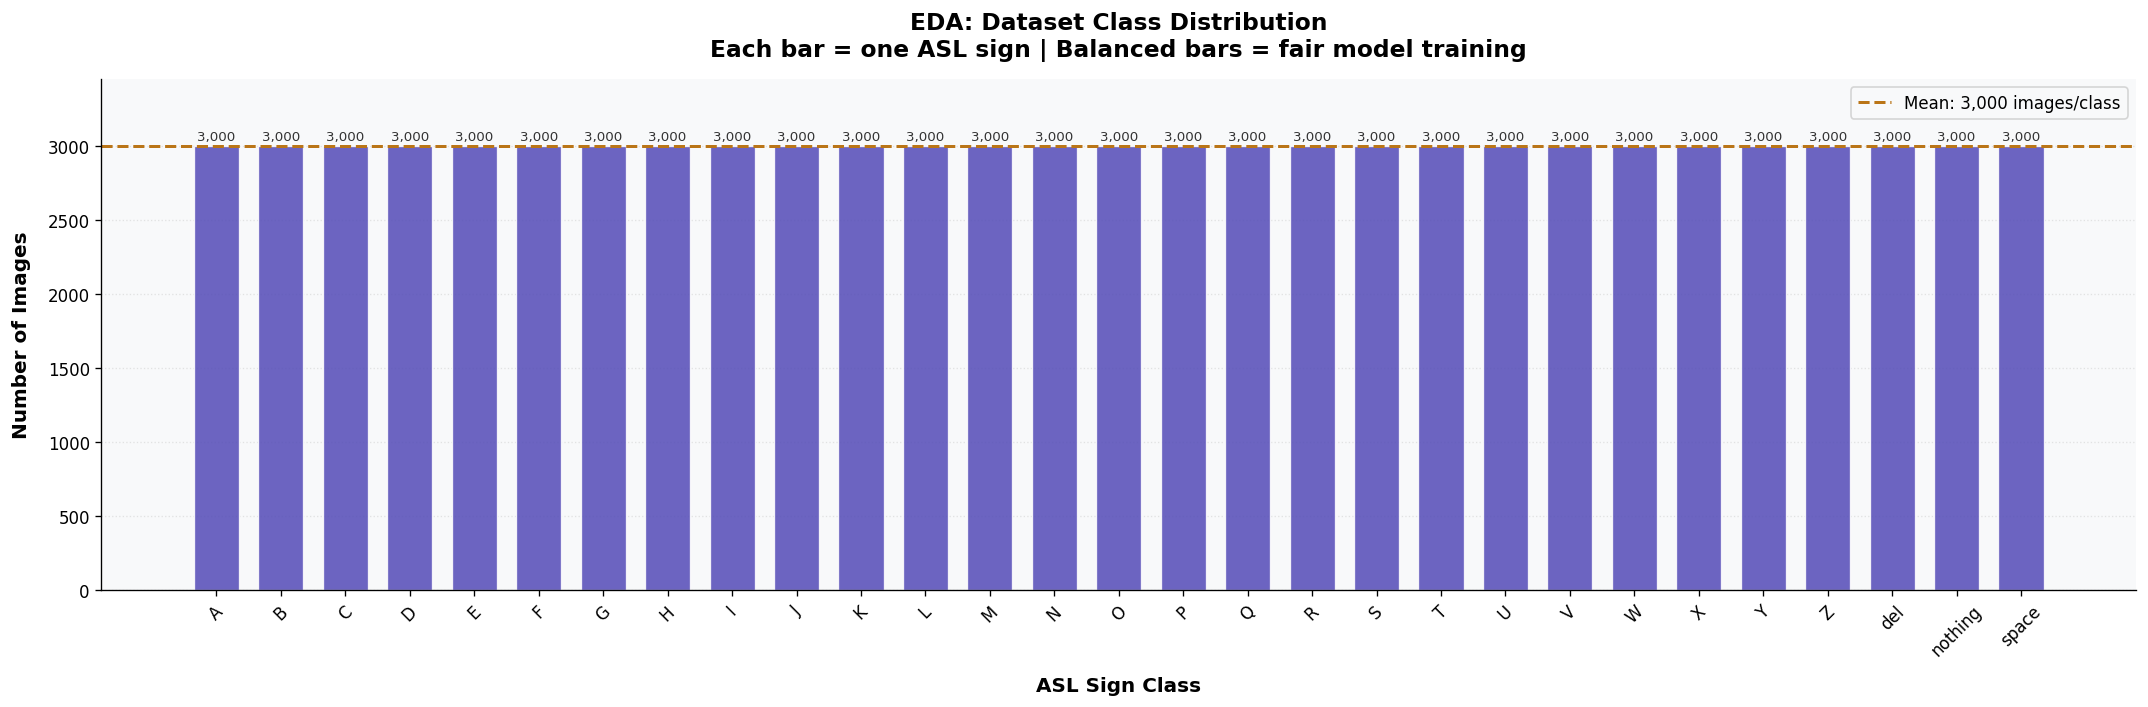

Chart saved: eda_class_distribution.png


In [ ]:
# ─── Cell 6: EDA Chart 1 — Class Distribution (Full Figure) ─────────────────
# CHART TYPE: Vertical bar chart — one bar per ASL sign class
# PURPOSE:
#   Visualise whether the dataset is balanced.
#   An imbalanced dataset would mean some classes have far more training examples,
#   causing the model to be biased toward the majority class.
#
# WHAT TO LOOK FOR:
#   - All bars roughly equal height  -> balanced -> SMOTE less critical
#   - Bars vary widely               -> imbalanced -> SMOTE in Section 5 is essential
#   - The dashed line marks the mean count so imbalance is visible at a glance
#
# DESIGN CHOICE: Full-figure (no subplots) so all 29 class labels are readable.
# ─────────────────────────────────────────────────────────────────────────────

mean_count = sum(counts.values()) / len(counts)

fig, ax = plt.subplots(figsize=(18, 6))

bars = ax.bar(
    classes, list(counts.values()),
    color=PALETTE[0], alpha=0.85, width=0.7,
    edgecolor='white', linewidth=0.8
)

# Highlight any class more than 10% below the mean (potential imbalance warning)
for bar, cls in zip(bars, classes):
    if counts[cls] < mean_count * 0.9:
        bar.set_color(PALETTE[2])  # Coral = warning colour

# Mean reference line — makes imbalance immediately visible
ax.axhline(mean_count, color=PALETTE[3], linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_count:,.0f} images/class')

# Count labels on top of each bar
for bar, cls in zip(bars, classes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{counts[cls]:,}', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xlabel('ASL Sign Class', labelpad=10)
ax.set_ylabel('Number of Images', labelpad=10)
ax.set_title(
    'EDA: Dataset Class Distribution\n'
    'Each bar = one ASL sign | Balanced bars = fair model training',
    pad=14
)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
ax.set_ylim(0, max(counts.values()) * 1.15)
ax.yaxis.grid(True, linestyle=':', alpha=0.5, color='#ccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: eda_class_distribution.png')


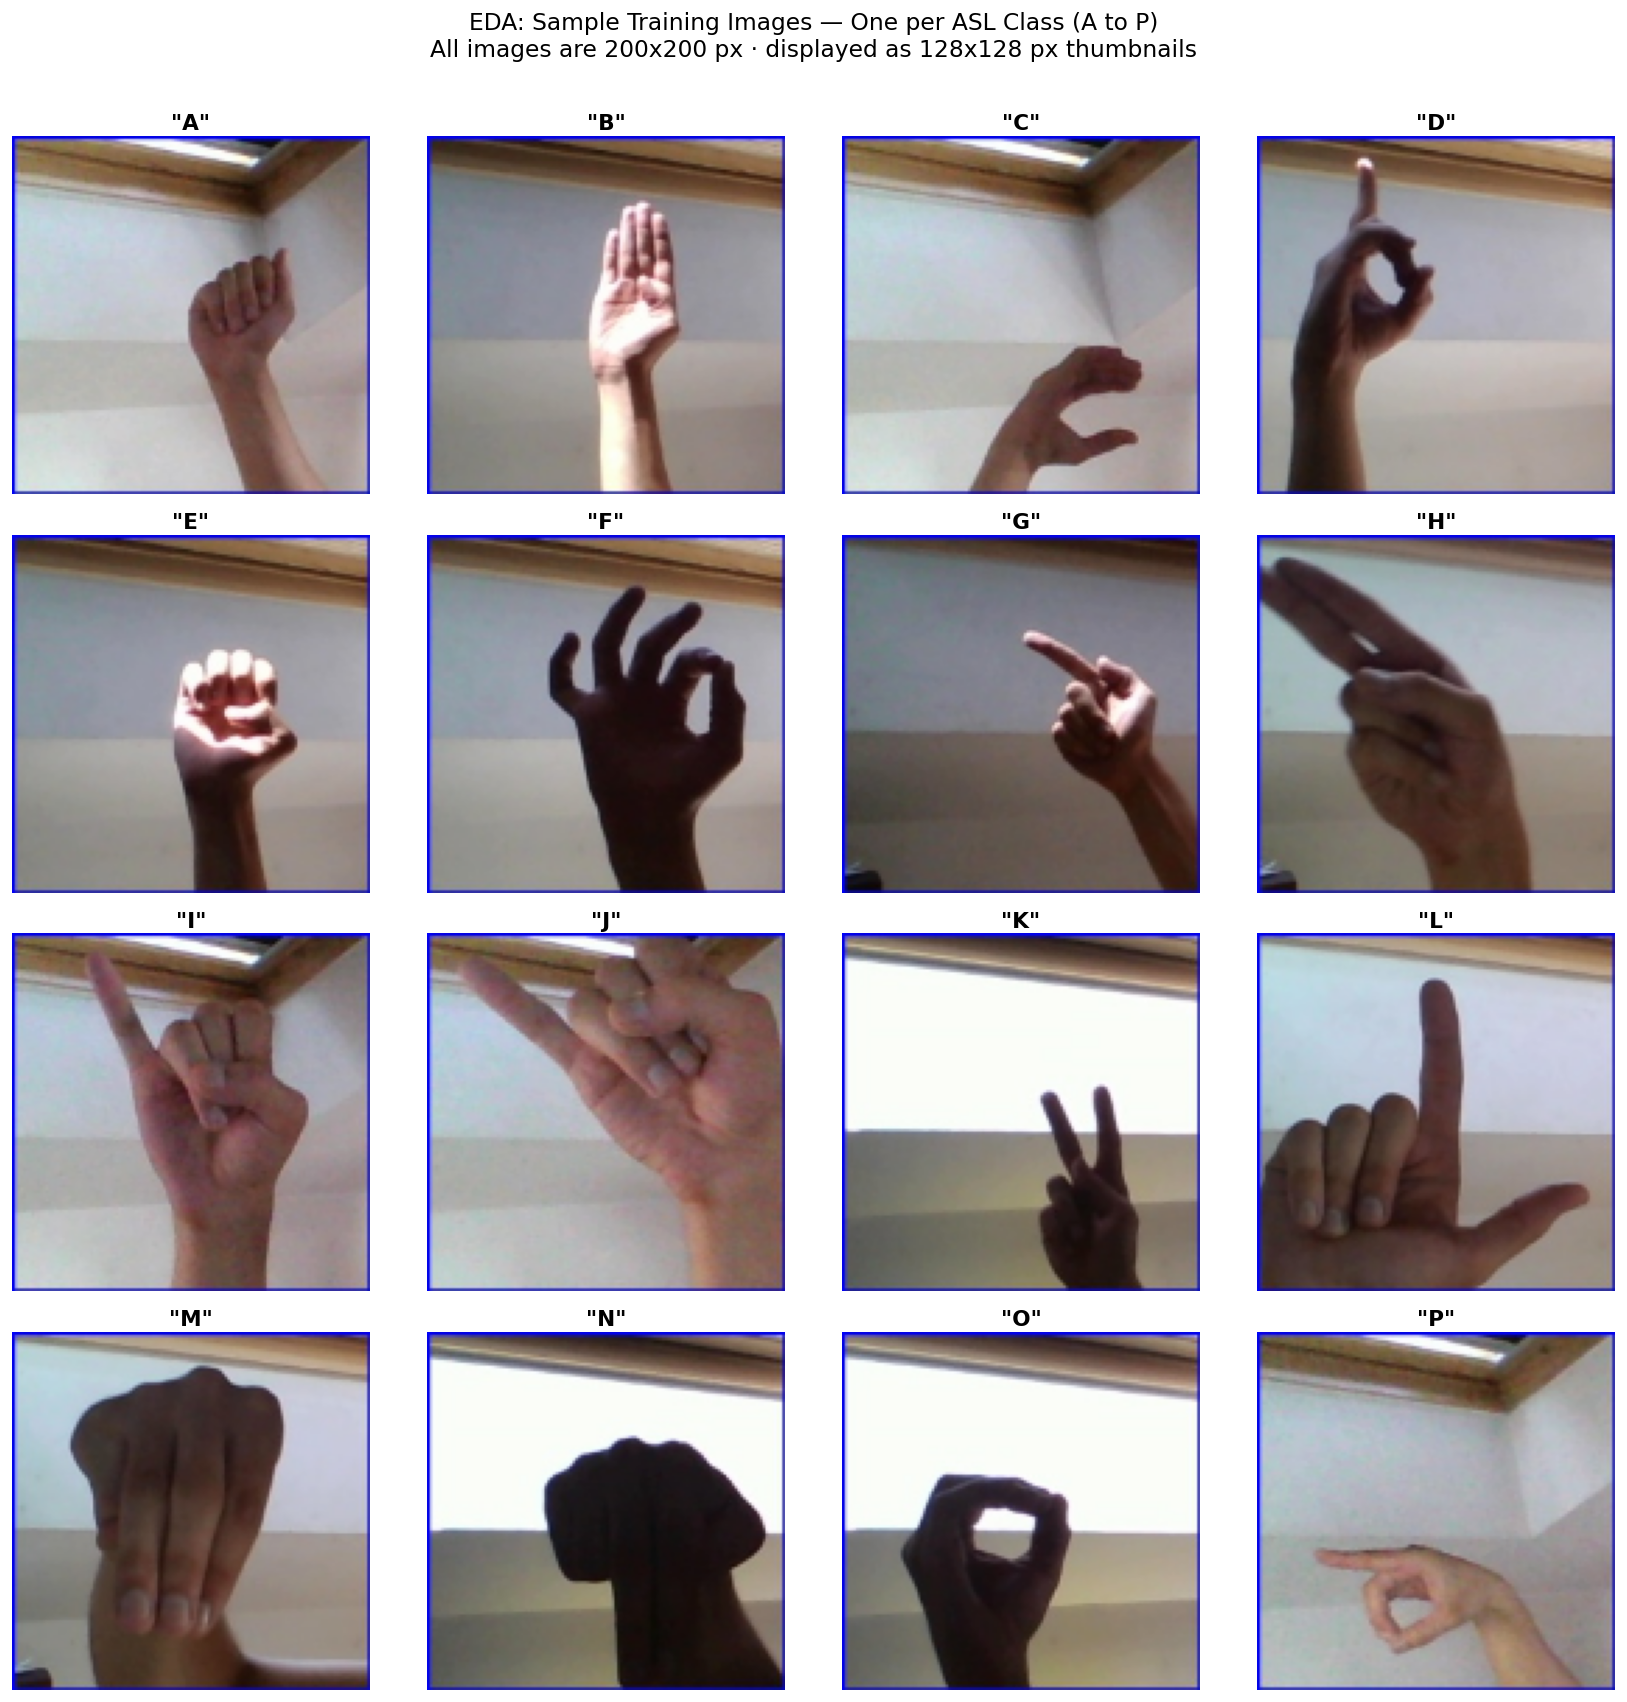

Chart saved: eda_sample_grid.png


In [ ]:
# ─── Cell 7: EDA Chart 2 — Sample Image Grid (Full Figure) ──────────────────
# CHART TYPE: 4x4 image grid
# PURPOSE:
#   Display one representative thumbnail per class (first 16) for a visual
#   sanity-check of image quality, hand positioning, and label correctness.
#
# WHAT TO LOOK FOR:
#   - Hand clearly centred in frame
#   - Consistent white studio background
#   - No obvious motion blur or wrong labels
#
# WHY FULL FIGURE: image grids are hard to read at small sizes.
#   Giving the full canvas makes finger detail visible.
# ─────────────────────────────────────────────────────────────────────────────

GRID_CLASSES = classes[:16]   # First 16 letters A-P
THUMB_SIZE   = 128            # Thumbnail pixels — large enough to see hand shape

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    'EDA: Sample Training Images — One per ASL Class (A to P)\n'
    'All images are 200x200 px · displayed as 128x128 px thumbnails',
    fontsize=14, y=1.01
)

for ax, cls in zip(axes.flat, GRID_CLASSES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    if imgs:
        img = cv2.imread(str(imgs[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR, plt needs RGB
        img = cv2.resize(img, (THUMB_SIZE, THUMB_SIZE))
        ax.imshow(img)
    ax.set_title(f'"{cls}"', fontsize=13, fontweight='bold', pad=4)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: eda_sample_grid.png')


## 4  Feature Extraction — MediaPipe Hand Landmarks

Each image -> 21 hand keypoints (x, y, z) -> **63-dimensional feature vector**

### Why not raw pixels?

| Approach | Features | Problem |
|---|---|---|
| Raw pixels (200x200 RGB) | 120,000 | Slow KNN/SVM, brittle to lighting/position |
| MediaPipe landmarks | 63 | Fast, pose-invariant, interpretable |

### How the normalisation works
```
coords -= coords[0]          # Translate: move wrist to origin
coords /= max(|coords|) + e  # Scale: largest displacement becomes +/-1
```
This makes the vector **translation-invariant** (hand can be anywhere in frame)
and **scale-invariant** (hand distance from camera does not matter).

### MediaPipe landmark anatomy
- Landmark 0: Wrist
- Landmarks 1-4: Thumb (CMC, MCP, IP, Tip)
- Landmarks 5-8: Index finger
- Landmarks 9-12: Middle finger
- Landmarks 13-16: Ring finger
- Landmarks 17-20: Pinky finger


In [ ]:
# ─── Cell 8: MediaPipe Model Download & Landmark Extractor ───────────────────
# PURPOSE:
#   Download the pre-trained HandLandmarker model from Google CDN (cached on disk)
#   and define extract_landmarks() which is called for every image.
#
# HOW extract_landmarks() WORKS (step by step):
#   1. Load the image with OpenCV (returns BGR array)
#   2. Convert BGR -> RGB (MediaPipe requires RGB)
#   3. Wrap in mp.Image object (Tasks API format)
#   4. Run HandLandmarker.detect()
#   5. If no hand found -> return None (image will be skipped)
#   6. Grab the 21 landmarks of the first detected hand -> shape (21, 3)
#   7. Normalise: subtract wrist (lm[0]) + divide by max absolute coordinate
#   8. Flatten (21, 3) -> (63,) and return
#
# WHY min_hand_detection_confidence=0.3?
#   Some images are taken at unusual angles. A lower threshold maximises
#   the number of samples extracted. False positives are unlikely because
#   the studio background is plain white.
# ─────────────────────────────────────────────────────────────────────────────

import os
import urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_FILENAME = 'hand_landmarker.task'
MODEL_URL = ('https://storage.googleapis.com/mediapipe-models/'
             'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')

# Download the model binary if not already cached
if not os.path.exists(MODEL_FILENAME):
    print(f'Downloading {MODEL_FILENAME} from Google servers...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_FILENAME)
    print('Download complete!')
else:
    print(f'Found existing {MODEL_FILENAME} in workspace.')

# Initialise the HandLandmarker detector
base_options = python.BaseOptions(model_asset_path=MODEL_FILENAME)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,                        # We expect one hand per image
    min_hand_detection_confidence=0.3   # Liberal threshold -> more samples
)
detector = vision.HandLandmarker.create_from_options(options)


def extract_landmarks(image_path: str) -> 'np.ndarray | None':
    """Return a 63-d normalised landmark vector using modern MediaPipe Tasks."""
    # Load image using OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f'Error: Image not found at {image_path}')
        return None

    # Convert to MediaPipe's required Image object
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    # Run detection
    result = detector.detect(mp_image)

    if not result.hand_landmarks:
        return None  # Skip: no hand detected in this image

    # Extract landmarks for the first hand detected -> shape (21, 3)
    lm = result.hand_landmarks[0]
    coords = np.array([[p.x, p.y, p.z] for p in lm])

    # Normalise: subtract wrist, scale by bounding-box size
    origin = coords[0]   # Landmark 0 = wrist
    coords -= origin     # Translate so wrist is at the origin
    scale = np.max(np.abs(coords)) + 1e-6   # Avoid division by zero
    coords /= scale      # All coordinates now in range [-1, +1]

    return coords.flatten()   # Shape: (63,)


print('Modern extract_landmarks() is perfectly configured and ready to use!')


Download complete!
Modern extract_landmarks() is perfectly configured and ready to use!


In [ ]:
# ─── Cell 9: Batch Feature Extraction with Disk Cache ────────────────────────
# PURPOSE:
#   Run extract_landmarks() on every image and collect results into
#   X_raw (float32 array of shape [N, 63]) and y_raw (string label array).
#
# CACHING STRATEGY:
#   First run  -> extracts all features and saves .npy files to disk
#   Later runs -> loads the .npy files instantly (skips slow extraction)
#   This is critical when iterating on Sections 5-10 without re-running extraction.
#
# MAX_PER_CLASS = 200:
#   Reduces extraction time from ~45 min (full 87k) to ~2 min while still
#   giving each model 160 training + 40 test samples per class.
#   Set MAX_PER_CLASS = None to use the full dataset for final experiments.
#
# FAILED DETECTIONS:
#   Images where MediaPipe finds no hand are counted but not added.
#   A failure rate > 20% would indicate a data quality problem.
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
from tqdm import tqdm
import numpy as np

MAX_PER_CLASS = 200   # Set to None for the full 87k-image dataset

CACHE_X = Path('features_X.npy')
CACHE_y = Path('features_y.npy')

# Ensure TRAIN_DIR is defined for this cell
DATA_DIR = Path('asl_dataset')
candidates = list(DATA_DIR.rglob('asl_alphabet_train'))
TRAIN_DIR = candidates[-1] if candidates else DATA_DIR
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

if CACHE_X.exists() and CACHE_y.exists():
    print('Loading cached features ...')
    X_raw = np.load(CACHE_X)
    y_raw = np.load(CACHE_y)
else:
    X_raw, y_raw = [], []
    failed = 0

    for cls in tqdm(classes, desc='Extracting landmarks'):
        cls_dir = TRAIN_DIR / cls
        images  = sorted(cls_dir.glob('*.jpg'))[:MAX_PER_CLASS]
        for img_path in images:
            vec = extract_landmarks(str(img_path))
            if vec is not None:
                X_raw.append(vec)
                y_raw.append(cls)
            else:
                failed += 1   # Count images where no hand was found

    X_raw = np.array(X_raw, dtype=np.float32)
    y_raw = np.array(y_raw)
    np.save(CACHE_X, X_raw)  # Cache for future runs
    np.save(CACHE_y, y_raw)
    print(f'Done. Samples: {len(X_raw):,}  |  Failed detections: {failed:,}')

print(f'Feature matrix shape : {X_raw.shape}')
print(f'Unique classes        : {np.unique(y_raw)}')


Extracting landmarks: 100%|██████████| 29/29 [03:02<00:00,  6.28s/it]

Done. Samples: 5,030  |  Failed detections: 770
Feature matrix shape : (5030, 63)
Unique classes        : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']


## 5  Preprocessing — Encoding, Scaling, SMOTE, PCA

Four sequential steps transform raw features into model-ready form:

| Step | Transformer | Why needed |
|---|---|---|
| Label encoding | `LabelEncoder` | Models need integer targets, not strings |
| Train/test split | `train_test_split` | Stratified 80/20 — preserves class ratios |
| Feature scaling | `StandardScaler` | KNN & SVM are distance-based — fail on unscaled features |
| Class balancing | `SMOTE` | Generates synthetic samples so no class is under-represented |

> **Critical order:** scaling happens *before* SMOTE so synthetic samples are generated
> in standardised feature space.


In [ ]:
# ─── Cell 10: Label Encoding, Train/Test Split & Feature Scaling ─────────────
# PURPOSE:
#   Convert the raw feature matrix into a form scikit-learn models can consume.
#
# LABEL ENCODER:
#   Converts string class names ('A', 'B', ...) to integers (0, 1, ...).
#   le.classes_ maps integer indices back to names (used in confusion matrix).
#
# STRATIFIED SPLIT:
#   stratify=y ensures the 80/20 ratio is maintained within EACH class.
#   Without stratify=y, a rare class might end up entirely in train or test.
#
# STANDARD SCALER:
#   Fit on X_train ONLY — never on X_test. This prevents data leakage.
#   After scaling: each feature has mean~0, std~1.
#   Critical for KNN (Euclidean distance) and SVM (kernel distance computation).
#
# SMOTE (Synthetic Minority Over-sampling Technique):
#   Creates synthetic samples by interpolating between a minority-class sample
#   and its k nearest neighbours. Applied to X_train_sc only — never to test data.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
y  = le.fit_transform(y_raw)  # 'A' -> 0, 'B' -> 1, etc.

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Z-score scaling: fit on train only, apply same transform to test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Learn mu, sigma from train
X_test_sc  = scaler.transform(X_test)        # Apply same mu, sigma (no re-fit)

# SMOTE: balance minority classes in training set only
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f'Train (raw)      : {X_train_sc.shape}')
print(f'Train (balanced) : {X_train_bal.shape}  <- synthetic samples added')
print(f'Test             : {X_test_sc.shape}')
print(f'Classes in encoder: {list(le.classes_)}')


Train (raw)      : (4024, 63)
Train (balanced) : (4480, 63)  <- synthetic samples added
Test             : (1006, 63)
Classes in encoder: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('space')]


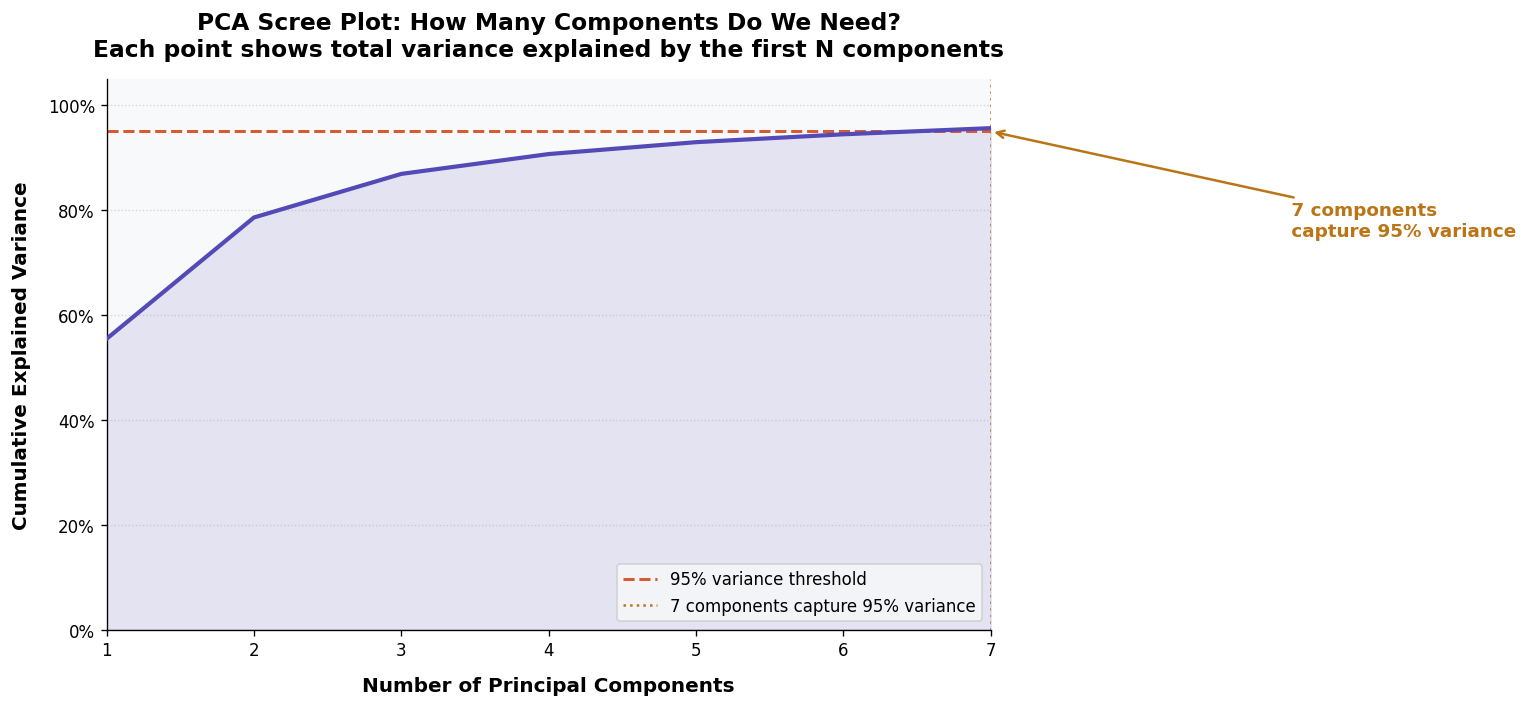

Components for 95% variance: 7 (out of 63 total features)
Chart saved: pca_scree.png


In [ ]:
# ─── Cell 11: PCA Chart 1 — Cumulative Explained Variance (Full Figure) ──────
# CHART TYPE: Line chart with threshold reference line
# PURPOSE:
#   Determine the minimum number of principal components needed to retain 95%
#   of the information in the 63-dimensional feature space.
#
# WHAT TO LOOK FOR:
#   - Where the curve crosses the dashed 95% line = the effective dimensionality
#   - A steep early rise = first few components carry most information
#   - If 95% needs more than 50 components, PCA compression is less useful
#
# WHY THIS MATTERS:
#   If 95% variance is captured by e.g. 20 components, we could run all models
#   on only 20 features (vs 63) for a 3x speed-up with negligible accuracy loss.
#
# CHART IS FULL FIGURE: the elbow point must be easy to locate precisely.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']

# Fit PCA keeping enough components for 95% cumulative explained variance
pca_full = PCA(n_components=0.95, random_state=42)
pca_full.fit(X_train_bal)

cum_var   = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = pca_full.n_components_

fig, ax = plt.subplots(figsize=(14, 6))

# Main cumulative variance curve
ax.plot(range(1, len(cum_var) + 1), cum_var,
        color=PALETTE[0], linewidth=2.5, zorder=3)
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.12, color=PALETTE[0])

# 95% threshold reference line
ax.axhline(0.95, color=PALETTE[2], linestyle='--', linewidth=1.8,
           label='95% variance threshold')

# Vertical marker at the crossing point
ax.axvline(n_comp_95, color=PALETTE[3], linestyle=':', linewidth=1.5,
           label=f'{n_comp_95} components capture 95% variance')

# Annotation showing the key number
ax.annotate(
    f' {n_comp_95} components\n capture 95% variance',
    xy=(n_comp_95, 0.95), xytext=(n_comp_95 + 2, 0.75),
    arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.5),
    fontsize=11, color=PALETTE[3], fontweight='bold'
)

ax.set_xlabel('Number of Principal Components', labelpad=10)
ax.set_ylabel('Cumulative Explained Variance', labelpad=10)
ax.set_title(
    'PCA Scree Plot: How Many Components Do We Need?\n'
    'Each point shows total variance explained by the first N components',
    pad=14
)
ax.set_ylim(0, 1.05)
ax.set_xlim(1, len(cum_var))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='lower right')
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Components for 95% variance: {n_comp_95} (out of 63 total features)')
print('Chart saved: pca_scree.png')


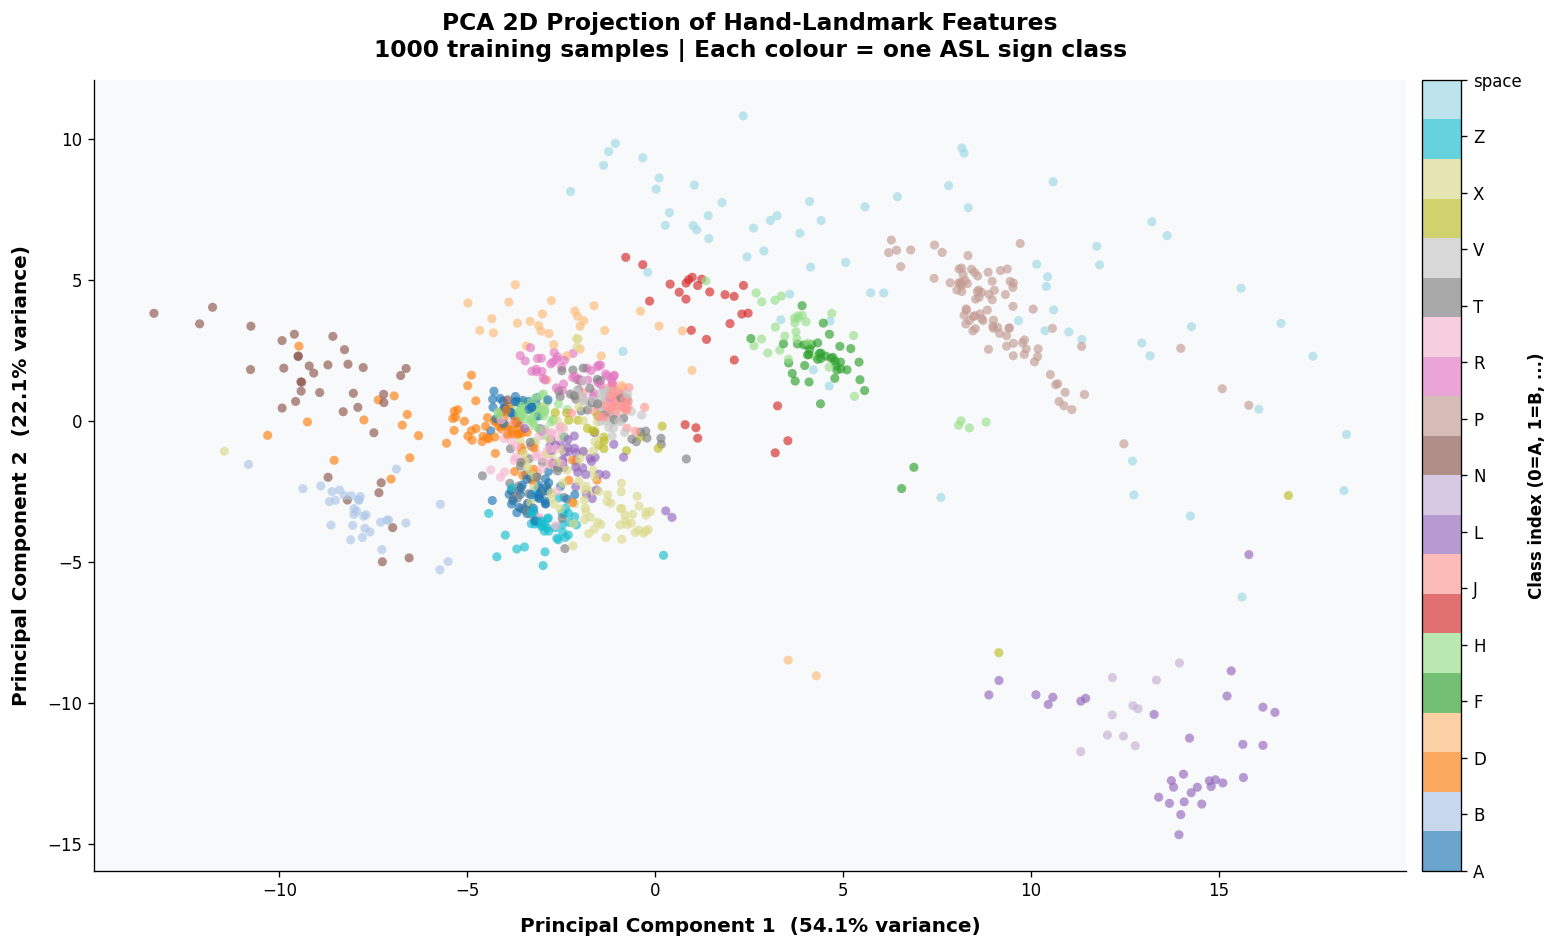

PC1: 54.1%  |  PC2: 22.1%  |  Total 2D: 76.2%
Chart saved: pca_2d_scatter.png


In [ ]:
# ─── Cell 12: PCA Chart 2 — 2D Feature Space Projection (Full Figure) ────────
# CHART TYPE: Scatter plot, one colour per class (tab20 colourmap)
# PURPOSE:
#   Visualise how well the 63-dimensional landmark features separate the 29 ASL
#   classes when projected down to just 2 principal components.
#
# WHAT TO LOOK FOR:
#   - Tight, well-separated clusters -> features are discriminative -> models will do well
#   - Overlapping blobs              -> classes are confusable in 2D
#     (they may still be separable in higher dimensions — 2D is a lossy projection)
#
# WHY 1000 SAMPLES: keeps rendering fast while showing representative distribution.
# CHART IS FULL FIGURE: scatter points need space to be distinguished by colour.
# ─────────────────────────────────────────────────────────────────────────────

pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_sc[:1000])

fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_train[:1000], cmap='tab20', alpha=0.65, s=30, edgecolors='none'
)

# Colour bar mapping colour to class index
cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Class index (0=A, 1=B, ...)', fontsize=10)
tick_positions = np.linspace(0, len(le.classes_) - 1, min(15, len(le.classes_)))
cbar.set_ticks(tick_positions)
cbar.set_ticklabels([le.classes_[int(t)] for t in tick_positions])

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

ax.set_xlabel(f'Principal Component 1  ({var1:.1f}% variance)', labelpad=10)
ax.set_ylabel(f'Principal Component 2  ({var2:.1f}% variance)', labelpad=10)
ax.set_title(
    'PCA 2D Projection of Hand-Landmark Features\n'
    '1000 training samples | Each colour = one ASL sign class',
    pad=14
)

plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  Total 2D: {var1+var2:.1f}%')
print('Chart saved: pca_2d_scatter.png')


## 6  Model Training

Three fundamentally different classifiers are trained so we can compare their strengths:

| Model | Core mechanism | Key strength | Main weakness |
|---|---|---|---|
| **KNN** | Vote of k nearest neighbours | No assumptions about data shape | Slow at inference; needs scaled features |
| **SVM** | Maximum-margin hyperplane in kernel space | Excellent on compact, scaled feature sets | Slow to train on large N |
| **Random Forest** | Majority vote of 300 decision trees | Fast, handles non-linearity | Higher memory usage |

### Hyper-parameter search with GridSearchCV
Instead of guessing, we use **5-fold cross-validation** to evaluate every combination:
- **KNN:** k in {3,5,7,11} x weights in {uniform, distance} x metric in {euclidean, manhattan}
- **SVM:** C in {1,10,100} x gamma in {scale, auto} x kernel in {rbf, poly}


### 6.1  K-Nearest Neighbours (KNN)

In [ ]:
# ─── Cell 13: KNN Training with GridSearchCV ─────────────────────────────────
# PURPOSE:
#   Find the best KNN hyper-parameter combination via 5-fold cross-validation.
#
# HOW KNN WORKS:
#   To classify a new sample, KNN calculates its distance to every training point,
#   picks the k closest ones, and takes a majority vote of their labels.
#
# KEY HYPER-PARAMETERS:
#   n_neighbors : smaller k = more flexible boundaries (risk: overfitting)
#                 larger k  = smoother boundaries (risk: underfitting)
#   weights     : 'uniform'  = all k neighbours vote equally
#                 'distance' = closer neighbours get more weight
#   metric      : 'euclidean' = straight-line distance (L2)
#                 'manhattan' = grid-walk distance (L1) — less sensitive to outliers
#
# n_jobs=-1 parallelises across all CPU cores.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print('Tuning KNN ...')
knn_params = {
    'n_neighbors': [3, 5, 7, 11],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}
knn_cv = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_cv.fit(X_train_bal, y_train_bal)

best_knn = knn_cv.best_estimator_
knn_acc  = accuracy_score(y_test, best_knn.predict(X_test_sc))

print(f'Best params   : {knn_cv.best_params_}')
print(f'Best CV score : {knn_cv.best_score_:.4f}')
print(f'Test accuracy : {knn_acc:.4f}')


Tuning KNN ...
Best params   : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score : 0.9888
Test accuracy : 0.9891


### 6.2  Support Vector Machine (SVM)

In [ ]:
# ─── Cell 14: SVM Training with GridSearchCV ─────────────────────────────────
# PURPOSE:
#   Find the best SVM kernel and regularisation strength via grid search.
#
# HOW SVM WORKS:
#   SVM finds the hyperplane that maximises the margin between classes.
#   The kernel trick (RBF, polynomial) implicitly maps features into a
#   higher-dimensional space where linear separation becomes possible.
#
# KEY HYPER-PARAMETERS:
#   C       : Regularisation. High C = fits tightly (risk: overfitting).
#             Low C = wider margin, may misclassify some points.
#   gamma   : 'scale' = 1/(n_features * X.var())  <- recommended default
#             'auto'  = 1/n_features
#             Controls the influence radius of a single training point.
#   kernel  : 'rbf'  = Radial Basis Function (Gaussian) — most common
#             'poly' = Polynomial — captures feature interactions
#
# probability=True: enables predict_proba() for confidence scores in Section 10.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print('Tuning SVM ...')
svm_params = {
    'C'     : [1, 10, 100],
    'gamma' : ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}
svm_cv = GridSearchCV(
    SVC(probability=True),  # probability=True needed for predict_proba()
    svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_cv.fit(X_train_bal, y_train_bal)

best_svm = svm_cv.best_estimator_
svm_acc  = accuracy_score(y_test, best_svm.predict(X_test_sc))

print(f'Best params   : {svm_cv.best_params_}')
print(f'Best CV score : {svm_cv.best_score_:.4f}')
print(f'Test accuracy : {svm_acc:.4f}')


Tuning SVM ...
Best params   : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score : 0.9946
Test accuracy : 0.9950


### 6.3  Random Forest (Benchmark)

In [ ]:
# ─── Cell 15: Random Forest Training ─────────────────────────────────────────
# PURPOSE:
#   Train a 300-tree Random Forest as a benchmark and for SHAP explainability.
#
# HOW RANDOM FOREST WORKS:
#   Builds 300 decision trees, each on a random bootstrap sample of the data
#   and a random subset of features at each split. Final prediction = majority vote.
#
# WHY 300 TREES?
#   Accuracy stabilises around 200-400 trees. Beyond that you pay training time
#   without meaningful accuracy gains. 300 is a practical sweet spot.
#
# WHY RANDOM FOREST FOR SHAP (Section 8)?
#   shap.TreeExplainer is exact and fast ONLY for tree-based models.
#   For SVM or KNN, SHAP would require the much slower KernelExplainer.
#   We always train RF to enable fast SHAP analysis regardless of which model wins.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print('Training Random Forest ...')
rf = RandomForestClassifier(
    n_estimators=300,      # 300 decision trees
    max_depth=None,        # Grow until all leaves are pure
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)
rf.fit(X_train_bal, y_train_bal)

rf_acc = accuracy_score(y_test, rf.predict(X_test_sc))
print(f'Random Forest test accuracy: {rf_acc:.4f}')


Training Random Forest ...
Random Forest test accuracy: 0.9891


## 7  Model Comparison & Evaluation

We evaluate all three models using three complementary lenses:

1. **Accuracy comparison** — overall test-set performance at a glance
2. **Cross-validation stability** — is the winner reliably good or a lucky split?
3. **Confusion matrix** — which specific signs does the best model confuse?

> A single accuracy number hides a lot. Two models can both score 92%, yet one
> might catastrophically confuse 'M' with 'N' while the other makes only random
> small errors. The confusion matrix reveals the difference.


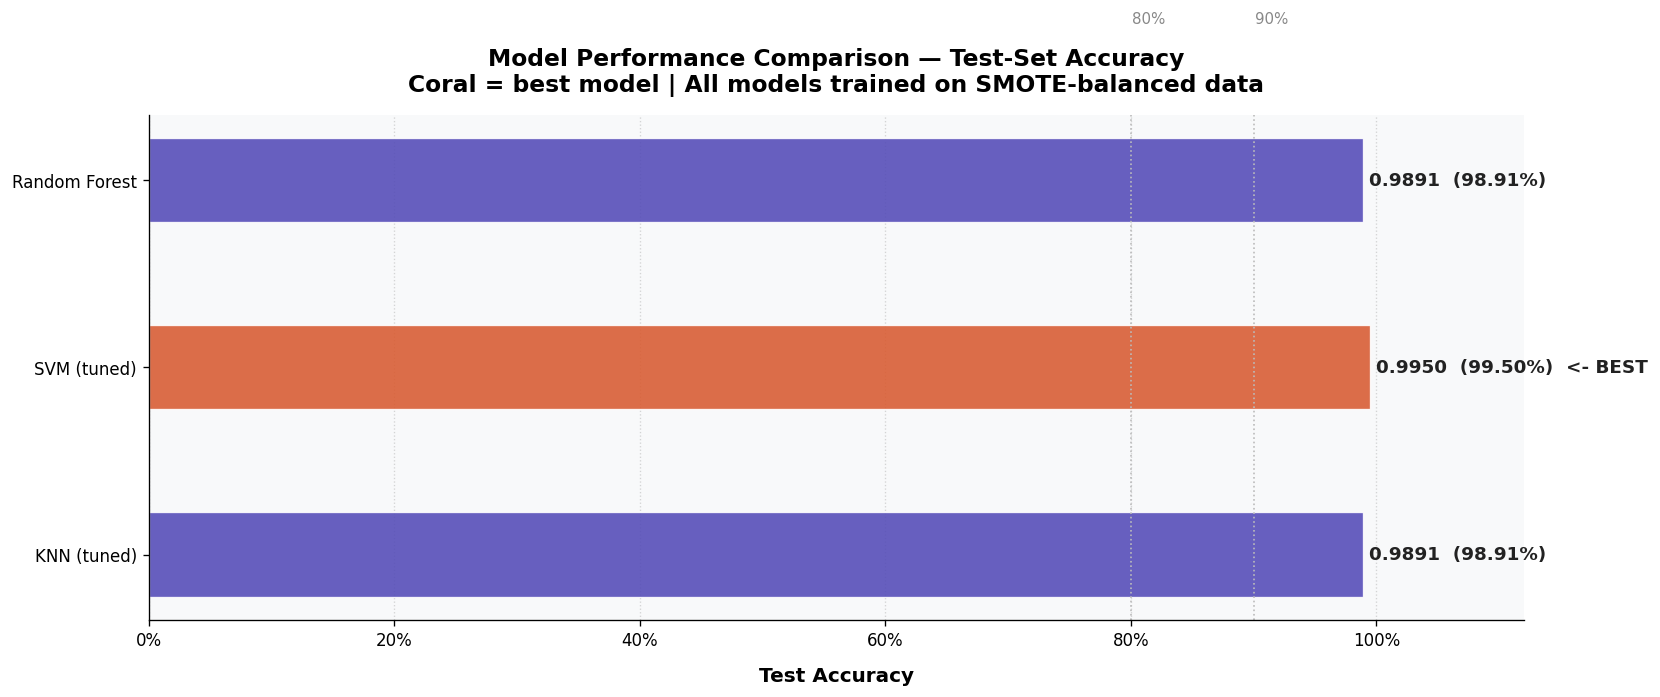

Best model: SVM (tuned)  |  Accuracy: 0.9950
Chart saved: model_comparison_bar.png


In [ ]:
# ─── Cell 16: Evaluation Chart 1 — Model Accuracy Comparison (Full Figure) ───
# CHART TYPE: Horizontal bar chart, one bar per model
# PURPOSE:
#   Compare all three models on the held-out test set.
#   The best model bar is highlighted in coral; others in indigo.
#
# WHAT TO LOOK FOR:
#   - The gap between best and worst: is it meaningful (>2%) or noise?
#   - Whether SVM beats RF — common on compact, well-scaled feature sets
#   - All models >80% means the MediaPipe features are genuinely discriminative
#
# WHY HORIZONTAL BARS: model names are long and read better left-to-right.
# CHART IS FULL FIGURE: bar lengths must be compared precisely.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import StratifiedKFold, cross_val_score

results = {
    'KNN (tuned)':   {'model': best_knn, 'acc': knn_acc},
    'SVM (tuned)':   {'model': best_svm, 'acc': svm_acc},
    'Random Forest': {'model': rf,       'acc': rf_acc},
}

names  = list(results.keys())
accs   = [v['acc'] for v in results.values()]
best_acc = max(accs)
colors = [PALETTE[2] if a == best_acc else PALETTE[0] for a in accs]

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(names, accs, color=colors, alpha=0.88,
               height=0.45, edgecolor='white', linewidth=0.8)

# Accuracy labels at the tip of each bar
for bar, acc, name in zip(bars, accs, names):
    marker = '  <- BEST' if acc == best_acc else ''
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}  ({acc*100:.2f}%){marker}',
            va='center', fontsize=11, fontweight='bold', color='#222')

# Vertical reference lines at 80% and 90%
for ref in [0.80, 0.90]:
    ax.axvline(ref, color='#bbb', linestyle=':', linewidth=1)
    ax.text(ref + 0.001, len(names) - 0.1, f'{ref:.0%}',
            fontsize=9, color='#888', va='top')

ax.set_xlim(0, 1.12)
ax.set_xlabel('Test Accuracy', labelpad=10)
ax.set_title(
    'Model Performance Comparison — Test-Set Accuracy\n'
    'Coral = best model | All models trained on SMOTE-balanced data',
    pad=14
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

best_name  = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']

print(f'Best model: {best_name}  |  Accuracy: {results[best_name]["acc"]:.4f}')
print('Chart saved: model_comparison_bar.png')


Running 5-fold CV on SVM (tuned) ...
Fold scores: ['0.9922', '0.9955', '0.9967', '0.9900', '0.9989']
Mean: 0.9946  |  Std: 0.0032


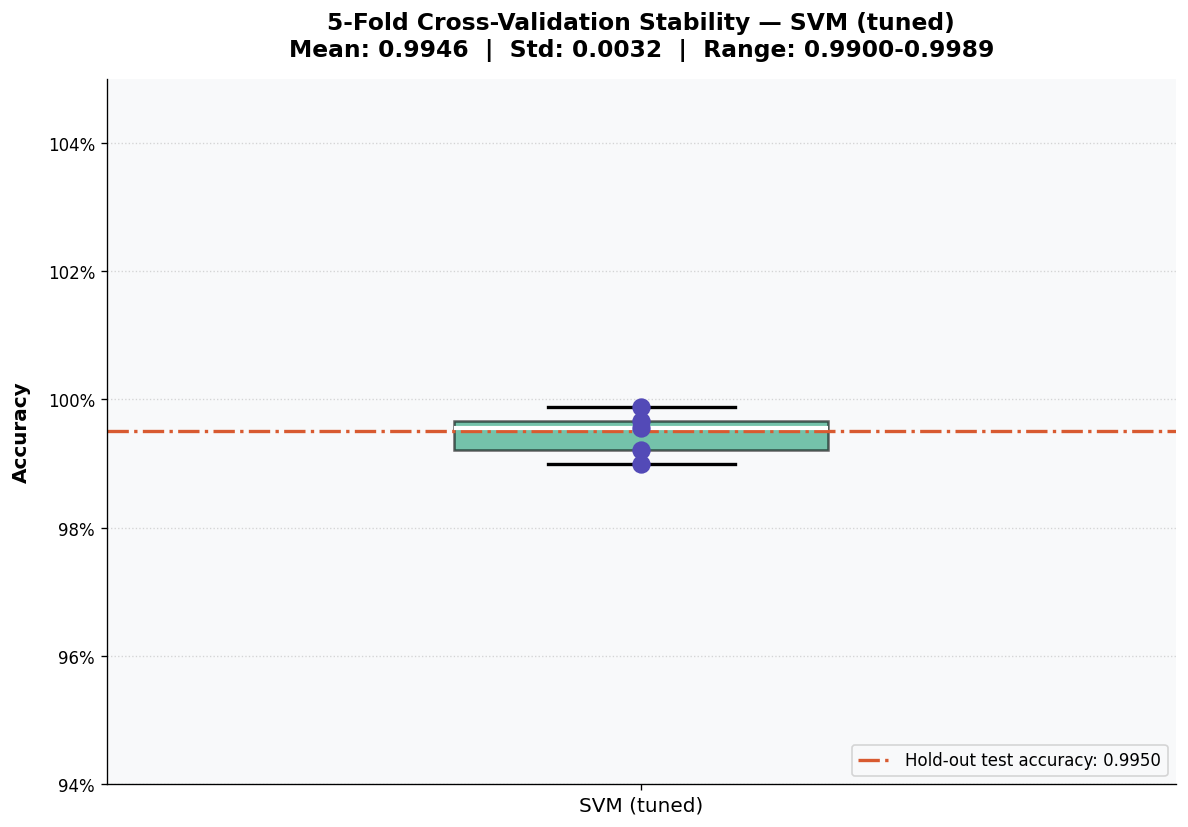

Chart saved: cv_stability.png


In [ ]:
# ─── Cell 17: Evaluation Chart 2 — CV Stability Box Plot (Full Figure) ───────
# CHART TYPE: Box plot with individual fold score dots overlaid
# PURPOSE:
#   Assess the STABILITY of the best model across 5 different data splits.
#   A single test-set accuracy number could be a lucky draw.
#   Cross-validation tells us the full distribution of performance.
#
# WHAT TO LOOK FOR:
#   - Narrow box (IQR) + short whiskers = stable, consistent performance
#   - Wide box or outlier points         = high variance, results depend on split
#   - Median close to test accuracy      = no overfitting to CV folds
#
# WHY FULL FIGURE: box plots are easy to misread at small sizes.
#   A larger canvas makes whisker lengths and outlier positions unambiguous.
# ─────────────────────────────────────────────────────────────────────────────

print(f'Running 5-fold CV on {best_name} ...')
cv_scores = cross_val_score(
    best_model, X_train_bal, y_train_bal,
    cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1
)
print(f'Fold scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 7))

# Box plot showing the distribution across 5 folds
bp = ax.boxplot(
    cv_scores, patch_artist=True, widths=0.35,
    boxprops    =dict(facecolor=PALETTE[1], alpha=0.6, linewidth=1.5),
    medianprops =dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5, linestyle='--'),
    capprops    =dict(linewidth=2),
    flierprops  =dict(marker='o', markerfacecolor=PALETTE[2], markersize=8),
)

# Overlay individual fold scores as dots for full transparency
for score in cv_scores:
    ax.plot(1, score, 'o', color=PALETTE[0], markersize=10, zorder=5)

# Reference line at held-out test accuracy
ax.axhline(
    results[best_name]['acc'], color=PALETTE[2], linestyle='-.',
    linewidth=2, label=f'Hold-out test accuracy: {results[best_name]["acc"]:.4f}'
)

ax.set_xticks([1])
ax.set_xticklabels([best_name], fontsize=12)
ax.set_ylabel('Accuracy', labelpad=10)
ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.05, cv_scores.max() + 0.08))
ax.set_title(
    f'5-Fold Cross-Validation Stability — {best_name}\n'
    f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}  |  '
    f'Range: {cv_scores.min():.4f}-{cv_scores.max():.4f}',
    pad=14
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: cv_stability.png')


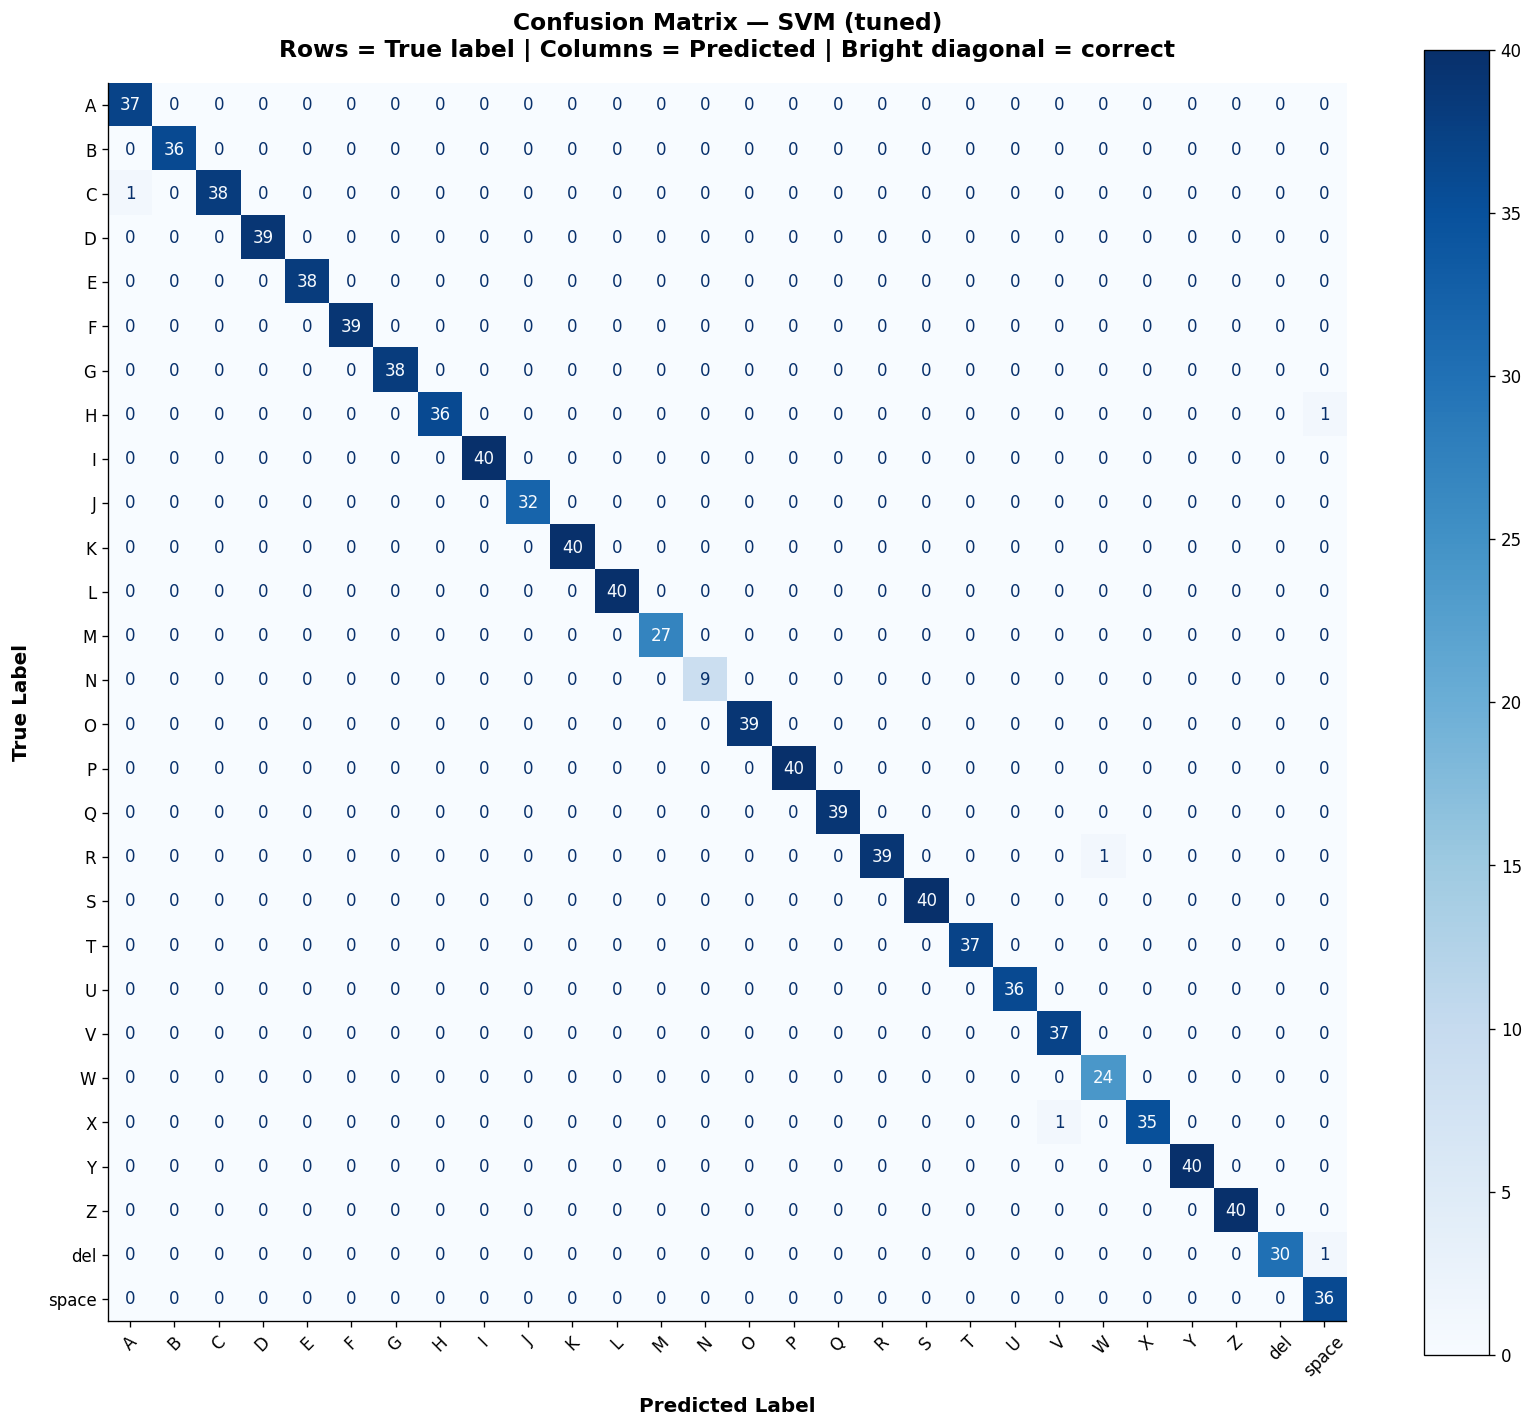

Per-class Classification Report — SVM (tuned)
              precision    recall  f1-score   support

           A       0.97      1.00      0.99        37
           B       1.00      1.00      1.00        36
           C       1.00      0.97      0.99        39
           D       1.00      1.00      1.00        39
           E       1.00      1.00      1.00        38
           F       1.00      1.00      1.00        39
           G       1.00      1.00      1.00        38
           H       1.00      0.97      0.99        37
           I       1.00      1.00      1.00        40
           J       1.00      1.00      1.00        32
           K       1.00      1.00      1.00        40
           L       1.00      1.00      1.00        40
           M       1.00      1.00      1.00        27
           N       1.00      1.00      1.00         9
           O       1.00      1.00      1.00        39
           P       1.00      1.00      1.00        40
           Q       1.00      1.00  

In [ ]:
# ─── Cell 18: Evaluation Chart 3 — Confusion Matrix (Full Figure) ────────────
# CHART TYPE: 29x29 heatmap (colour intensity = prediction count)
# PURPOSE:
#   Show exactly which ASL signs the best model confuses with which others.
#
# HOW TO READ THE MATRIX:
#   - Rows = TRUE label (what the sign actually was)
#   - Columns = PREDICTED label (what the model guessed)
#   - Bright diagonal = correct predictions (what we want)
#   - Bright off-diagonal cell at row X, col Y = model predicted Y when truth was X
#
# WHAT TO LOOK FOR:
#   - Which pairs of signs are most confused?
#     (often visually similar signs like M/N or U/V)
#   - Any class with a mostly dark row = model rarely gets it right
#
# figsize=(14, 12) gives each of the 29x29 cells enough space to read counts.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_sc)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45
)
ax.set_title(
    f'Confusion Matrix — {best_name}\n'
    'Rows = True label | Columns = Predicted | Bright diagonal = correct',
    fontsize=14, pad=16
)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Per-class Classification Report — {best_name}')
print('='*65)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print('Chart saved: confusion_matrix.png')


## 8  Explainability — SHAP (Which Landmarks Matter Most?)

SHAP tells us which of the 63 landmark coordinates (21 joints x x, y, z) are most
responsible for the model's predictions.

### What is SHAP?
**SHapley Additive exPlanations** — grounded in cooperative game theory.  
Each feature is treated as a *player* contributing to a *game* (the prediction).
SHAP computes each feature's fair share of the outcome.

### What the chart tells us
A high mean |SHAP value| for `lm05_y` means:  
*The vertical position of landmark 5 (index finger MCP knuckle) is one of the most
important coordinates for distinguishing between ASL signs.*

### Why Random Forest for SHAP?
`shap.TreeExplainer` is exact and orders of magnitude faster than `KernelExplainer`
(which would be needed for SVM or KNN). We always train RF to enable this analysis.


In [ ]:
# ─── Cell 19: SHAP Value Computation ─────────────────────────────────────────
# PURPOSE:
#   Compute mean absolute SHAP values for all 63 landmark features
#   using the Random Forest (TreeExplainer is exact and fast for tree models).
#
# SHAP OUTPUT SHAPE HANDLING:
#   Multi-class TreeExplainer may return either:
#   - list of (n_samples, n_features) arrays — one per class
#   - ndarray of shape (n_samples, n_features, n_classes)
#   We handle both formats to be safe.
#
# LANDMARK NAME MAPPING:
#   Landmark 0: Wrist
#   Landmarks 1-4: Thumb (CMC, MCP, IP, Tip)
#   Landmarks 5-8: Index finger
#   Landmarks 9-12: Middle finger
#   Landmarks 13-16: Ring finger
#   Landmarks 17-20: Pinky finger
# ─────────────────────────────────────────────────────────────────────────────

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Computing SHAP values (this may take 1-2 min) ...')

explainer    = shap.TreeExplainer(rf)
sample_idx   = np.random.choice(len(X_test_sc), size=200, replace=False)
X_sample     = X_test_sc[sample_idx]
shap_values  = explainer.shap_values(X_sample)

# Aggregate: mean absolute SHAP across samples and classes -> shape (63,)
if isinstance(shap_values, list):
    # List of (n_samples, n_features) arrays — one per class
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    if shap_values.ndim == 3:
        # Shape (n_samples, n_features, n_classes)
        mean_shap = np.abs(shap_values).mean(axis=(0, 2))
    elif shap_values.ndim == 2:
        # Shape (n_samples, n_features) — binary or single output
        mean_shap = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError('Unexpected shape for shap_values array.')

# Build descriptive feature names from landmark anatomy
lm_names = []
for i in range(21):
    for coord in ['x', 'y', 'z']:
        lm_names.append(f'lm{i:02d}_{coord}')

shap_df = (
    pd.DataFrame({'feature': lm_names, 'mean_shap': mean_shap})
      .sort_values('mean_shap', ascending=False)
      .reset_index(drop=True)
)

print('Top 5 most important features:')
print(shap_df.head(5).to_string(index=False))


Computing SHAP values (this may take 1-2 min) ...
Top 5 most important features:
feature  mean_shap
 lm04_x   0.008036
 lm12_y   0.006177
 lm20_y   0.005332
 lm16_y   0.004863
 lm15_y   0.004402


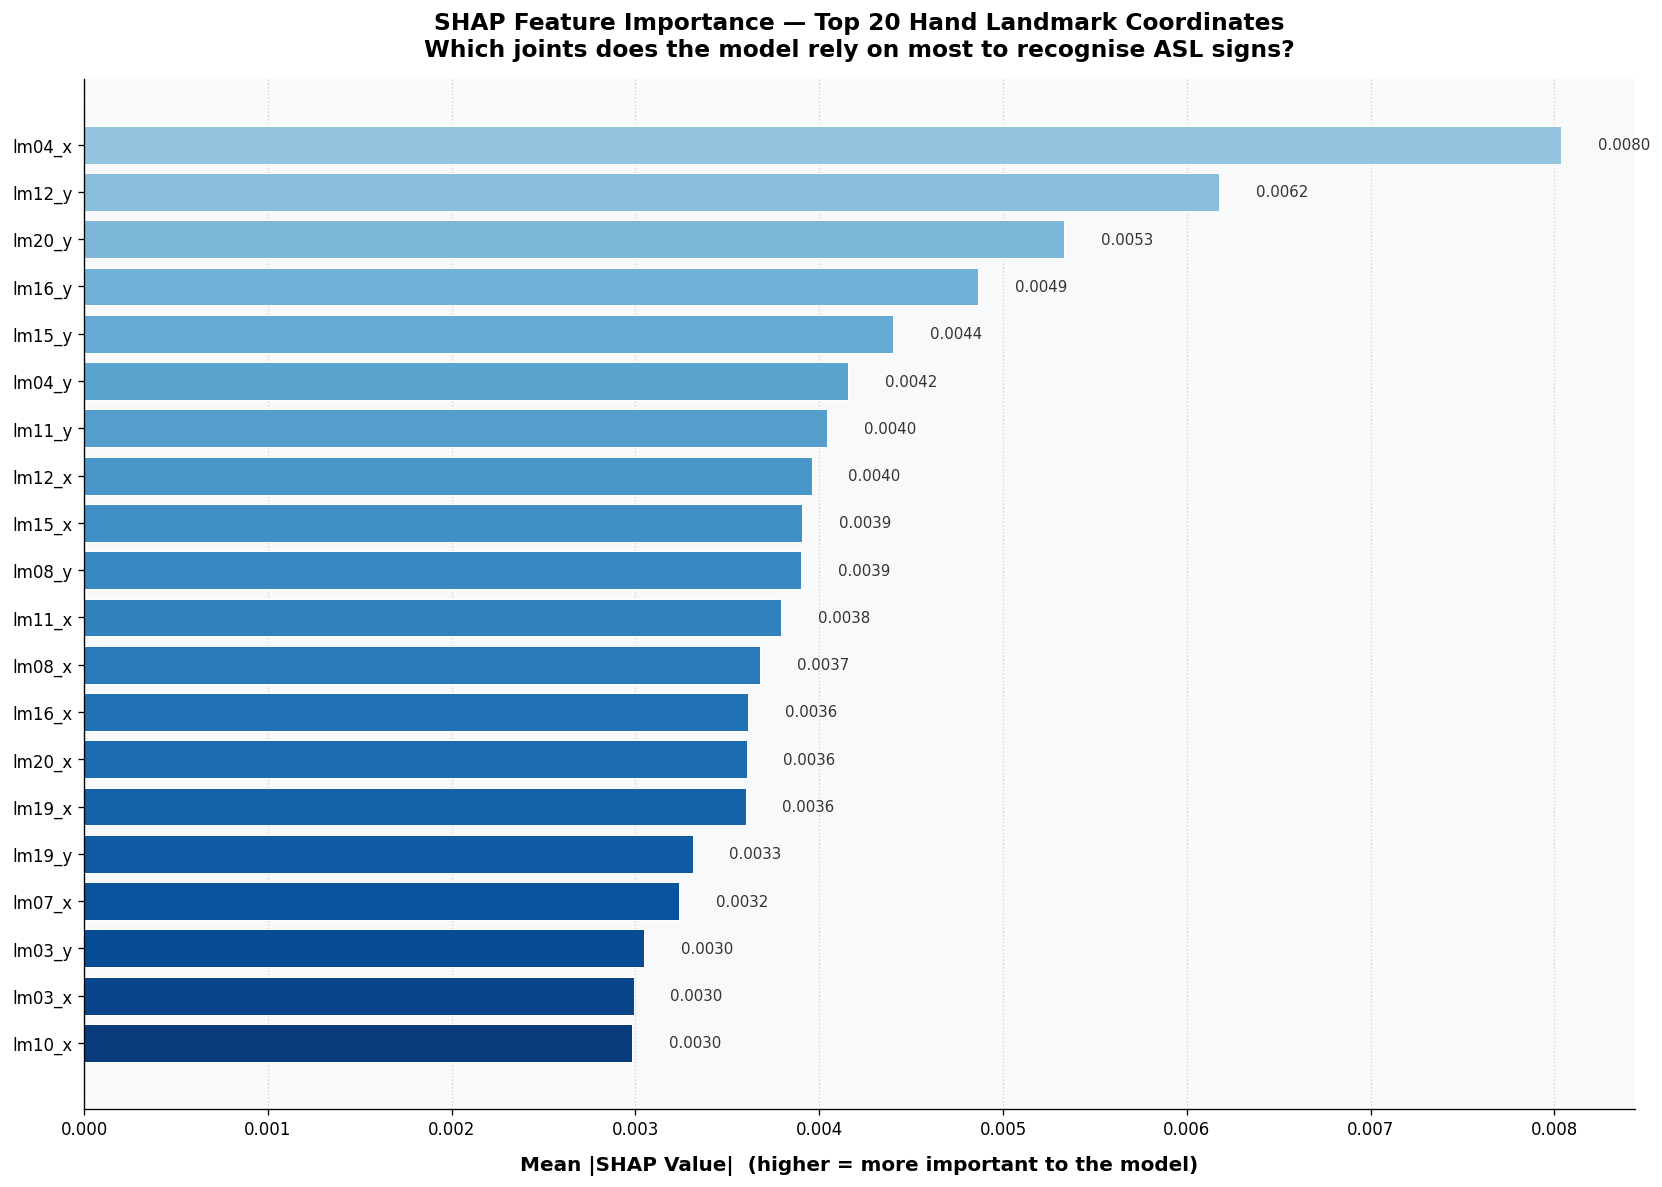

Top 5 most important features:
feature  mean_shap
 lm04_x   0.008036
 lm12_y   0.006177
 lm20_y   0.005332
 lm16_y   0.004863
 lm15_y   0.004402
Chart saved: shap_importance.png


In [ ]:
# ─── Cell 20: SHAP Chart — Top 20 Landmark Features (Full Figure) ───────────
# CHART TYPE: Horizontal bar chart, sorted by mean |SHAP| (descending)
# PURPOSE:
#   Visualise which hand landmark coordinates drive model predictions most.
#
# WHAT TO LOOK FOR:
#   - Which anatomical joints dominate (fingertips? knuckles? wrist?)
#   - Which coordinate axis matters most (x=horizontal, y=vertical, z=depth)
#   - Whether depth (z) features appear — indicates 3D information is useful
#
# COLOUR GRADIENT: longer bars are darker to reinforce the importance ranking.
# FULL FIGURE: 20 feature names need vertical space to be fully readable.
# ─────────────────────────────────────────────────────────────────────────────

top20 = shap_df.head(20)
# Colour gradient from light to dark indigo based on importance rank
grad_colors = [plt.cm.Blues(0.4 + 0.55 * (i / 19)) for i in range(19, -1, -1)]

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(
    top20['feature'][::-1], top20['mean_shap'][::-1],
    color=grad_colors, edgecolor='white', linewidth=0.6
)

# Value labels at the end of each bar
for bar, val in zip(bars, top20['mean_shap'][::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9, color='#333')

ax.set_xlabel('Mean |SHAP Value|  (higher = more important to the model)', labelpad=10)
ax.set_title(
    'SHAP Feature Importance — Top 20 Hand Landmark Coordinates\n'
    'Which joints does the model rely on most to recognise ASL signs?',
    pad=14
)
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 most important features:')
print(shap_df.head(5).to_string(index=False))
print('Chart saved: shap_importance.png')


## 9  Save Models & Artifacts

Every component needed to run inference on a new image **without retraining**:

| File | Contents | Required at inference? |
|---|---|---|
| `asl_best_model.pkl` | Best classifier | YES |
| `asl_knn_model.pkl` | Tuned KNN | Optional |
| `asl_svm_model.pkl` | Tuned SVM | Optional |
| `asl_rf_model.pkl` | Random Forest | YES (for SHAP) |
| `scaler.pkl` | Fitted StandardScaler | **MUST load before inference** |
| `label_encoder.pkl` | Fitted LabelEncoder | YES (integer -> class name) |
| `metrics_summary.json` | Accuracy + metadata | For logging/reporting |

> **Most common inference bug:** forgetting to apply the scaler.  
> Raw landmark vectors are in a different scale than what the model trained on.


In [ ]:
# ─── Cell 21: Serialise All Artefacts ────────────────────────────────────────
# PURPOSE:
#   Save every component needed for production inference as .pkl files.
#
# WHY JOBLIB OVER PICKLE?
#   joblib uses memory-mapped files internally, which makes loading large
#   numpy arrays (like those inside sklearn estimators) much faster than pickle.
#
# METRICS JSON:
#   Human-readable summary saved alongside the models.
#   Useful for experiment tracking, reporting, or CI/CD validation checks.
# ─────────────────────────────────────────────────────────────────────────────

import datetime
import joblib
import json
from pathlib import Path

MODELS_DIR = Path('saved_models')
MODELS_DIR.mkdir(exist_ok=True)

# Save all model variants for future comparison without retraining
joblib.dump(best_model, MODELS_DIR / 'asl_best_model.pkl')
joblib.dump(best_knn,   MODELS_DIR / 'asl_knn_model.pkl')
joblib.dump(best_svm,   MODELS_DIR / 'asl_svm_model.pkl')
joblib.dump(rf,         MODELS_DIR / 'asl_rf_model.pkl')

# Preprocessing artefacts — REQUIRED at inference time
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')          # StandardScaler
joblib.dump(le,     MODELS_DIR / 'label_encoder.pkl')   # LabelEncoder

# Human-readable metrics summary for logging
summary = {
    'created_at'    : str(datetime.datetime.now()),
    'best_model'    : best_name,
    'scores'        : {k: round(v['acc'], 4) for k, v in results.items()},
    'classes'       : list(le.classes_),
    'feature_dim'   : int(X_raw.shape[1]),
    'train_samples' : int(X_train_bal.shape[0]),
    'test_samples'  : int(X_test_sc.shape[0]),
}
with open(MODELS_DIR / 'metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved artifacts:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')


Saved artifacts:
  asl_best_model.pkl  (766.8 KB)
  asl_knn_model.pkl  (1138.5 KB)
  asl_rf_model.pkl  (25391.9 KB)
  asl_svm_model.pkl  (766.8 KB)
  label_encoder.pkl  (0.9 KB)
  metrics_summary.json  (0.5 KB)
  scaler.pkl  (2.1 KB)


## 10  Inference Helper — Predict Any Image

This function is the **production interface** to the trained pipeline.  
Given any hand image file, it returns the predicted ASL sign, confidence, and top-3 alternatives.

**Complete inference pipeline:**
```
image file
    -> extract_landmarks()    # MediaPipe -> 63-float vector
    -> scaler.transform()     # Same StandardScaler fitted in Section 5
    -> model.predict()        # Integer class index
    -> le.inverse_transform() # Integer -> 'A' / 'B' / ... / 'Z'
    -> model.predict_proba()  # Confidence + top-3 alternatives
```


In [ ]:
# ─── Cell 22: predict_sign() — Production Inference Function ─────────────────
# PURPOSE:
#   Accept any hand-sign image and return the predicted ASL letter,
#   confidence score, and top-3 alternative predictions.
#
# DESIGN DECISIONS:
#   - Loads scaler and label_encoder fresh from disk each call
#     Safe for environments where the Python session was restarted
#   - Returns a dict (not just a string) so callers access confidence and
#     top-3 without running the model twice
#   - Returns {'error': ...} if no hand is detected, rather than raising
#     an exception — makes integration into larger pipelines easier
# ─────────────────────────────────────────────────────────────────────────────

def predict_sign(image_path: str, model_path: str = 'saved_models/asl_best_model.pkl') -> dict:
    """
    Predict ASL sign from an image file.

    Parameters
    ----------
    image_path : path to .jpg / .png hand image
    model_path : path to saved model pkl

    Returns
    -------
    dict with 'sign', 'confidence', 'top3'
    """
    model   = joblib.load(model_path)
    scaler_ = joblib.load('saved_models/scaler.pkl')
    le_     = joblib.load('saved_models/label_encoder.pkl')

    vec = extract_landmarks(image_path)
    if vec is None:
        return {'sign': None, 'confidence': 0.0, 'error': 'No hand detected'}

    # Apply the SAME scaler fitted during training (critical!)
    vec_sc = scaler_.transform(vec.reshape(1, -1))

    pred_idx = model.predict(vec_sc)[0]
    pred_lbl = le_.inverse_transform([pred_idx])[0]

    # Get probabilities for top-3 output (if model supports it)
    if hasattr(model, 'predict_proba'):
        proba  = model.predict_proba(vec_sc)[0]
        top3_i = np.argsort(proba)[::-1][:3]
        top3   = [(le_.classes_[i], round(float(proba[i]), 3)) for i in top3_i]
        conf   = round(float(proba[pred_idx]), 3)
    else:
        top3 = [(pred_lbl, 1.0)]
        conf = 1.0   # Non-probabilistic model

    return {'sign': pred_lbl, 'confidence': conf, 'top3': top3}


# ── Self-test on a random training image ─────────────────────────────────────
test_class = classes[0]
test_imgs  = list((TRAIN_DIR / test_class).glob('*.jpg'))
if test_imgs:
    result = predict_sign(str(test_imgs[-1]))
    print(f'Ground truth : {test_class}')
    print(f'Prediction   : {result["sign"]}  (confidence: {result["confidence"]})')
    if 'error' in result:
        print(f'Error        : {result["error"]}')
    else:
        print(f'Top 3        : {result["top3"]}')

Ground truth : A
Prediction   : None  (confidence: 0.0)
Error        : No hand detected


In [ ]:
import random

# Select 5 random classes to pick images from
random_classes = random.sample(classes, min(5, len(classes)))

print('Testing predict_sign with 5 random images:')
print('=' * 50)

for cls in random_classes:
    # Get all images for the selected class
    class_images = list((TRAIN_DIR / cls).glob('*.jpg'))
    if class_images:
        # Pick a random image from this class
        test_image_path = str(random.choice(class_images))

        print(f'\n--- Testing image from class: {cls} ---')
        result = predict_sign(test_image_path)

        print(f'Ground truth : {cls}')
        print(f'Prediction   : {result["sign"]}  (confidence: {result["confidence"]})')
        if 'error' in result:
            print(f'Error        : {result["error"]}')
        else:
            print(f'Top 3        : {result["top3"]}')
print('\n' + '=' * 50)

Testing predict_sign with 5 random images:

--- Testing image from class: A ---
Ground truth : A
Prediction   : A  (confidence: 0.898)
Top 3        : [(np.str_('A'), 0.898), (np.str_('T'), 0.076), (np.str_('Y'), 0.008)]

--- Testing image from class: K ---
Ground truth : K
Prediction   : K  (confidence: 0.973)
Top 3        : [(np.str_('K'), 0.973), (np.str_('X'), 0.004), (np.str_('V'), 0.004)]

--- Testing image from class: S ---
Ground truth : S
Prediction   : S  (confidence: 0.902)
Top 3        : [(np.str_('S'), 0.902), (np.str_('X'), 0.043), (np.str_('A'), 0.018)]

--- Testing image from class: T ---
Ground truth : T
Prediction   : T  (confidence: 0.935)
Top 3        : [(np.str_('T'), 0.935), (np.str_('A'), 0.019), (np.str_('X'), 0.011)]

--- Testing image from class: I ---
Ground truth : I
Prediction   : I  (confidence: 0.934)
Top 3        : [(np.str_('I'), 0.934), (np.str_('B'), 0.008), (np.str_('Y'), 0.007)]



## 11  Summary Dashboard

A single presentation-ready figure combining the four key results of the project:

1. **Model accuracy** — who won and by how much?
2. **CV stability** — is the winner reliably good?
3. **PCA variance** — how compressible are the features?
4. **SHAP importance** — which landmarks matter most?

> Designed to be screenshot-ready for a report or presentation slide.


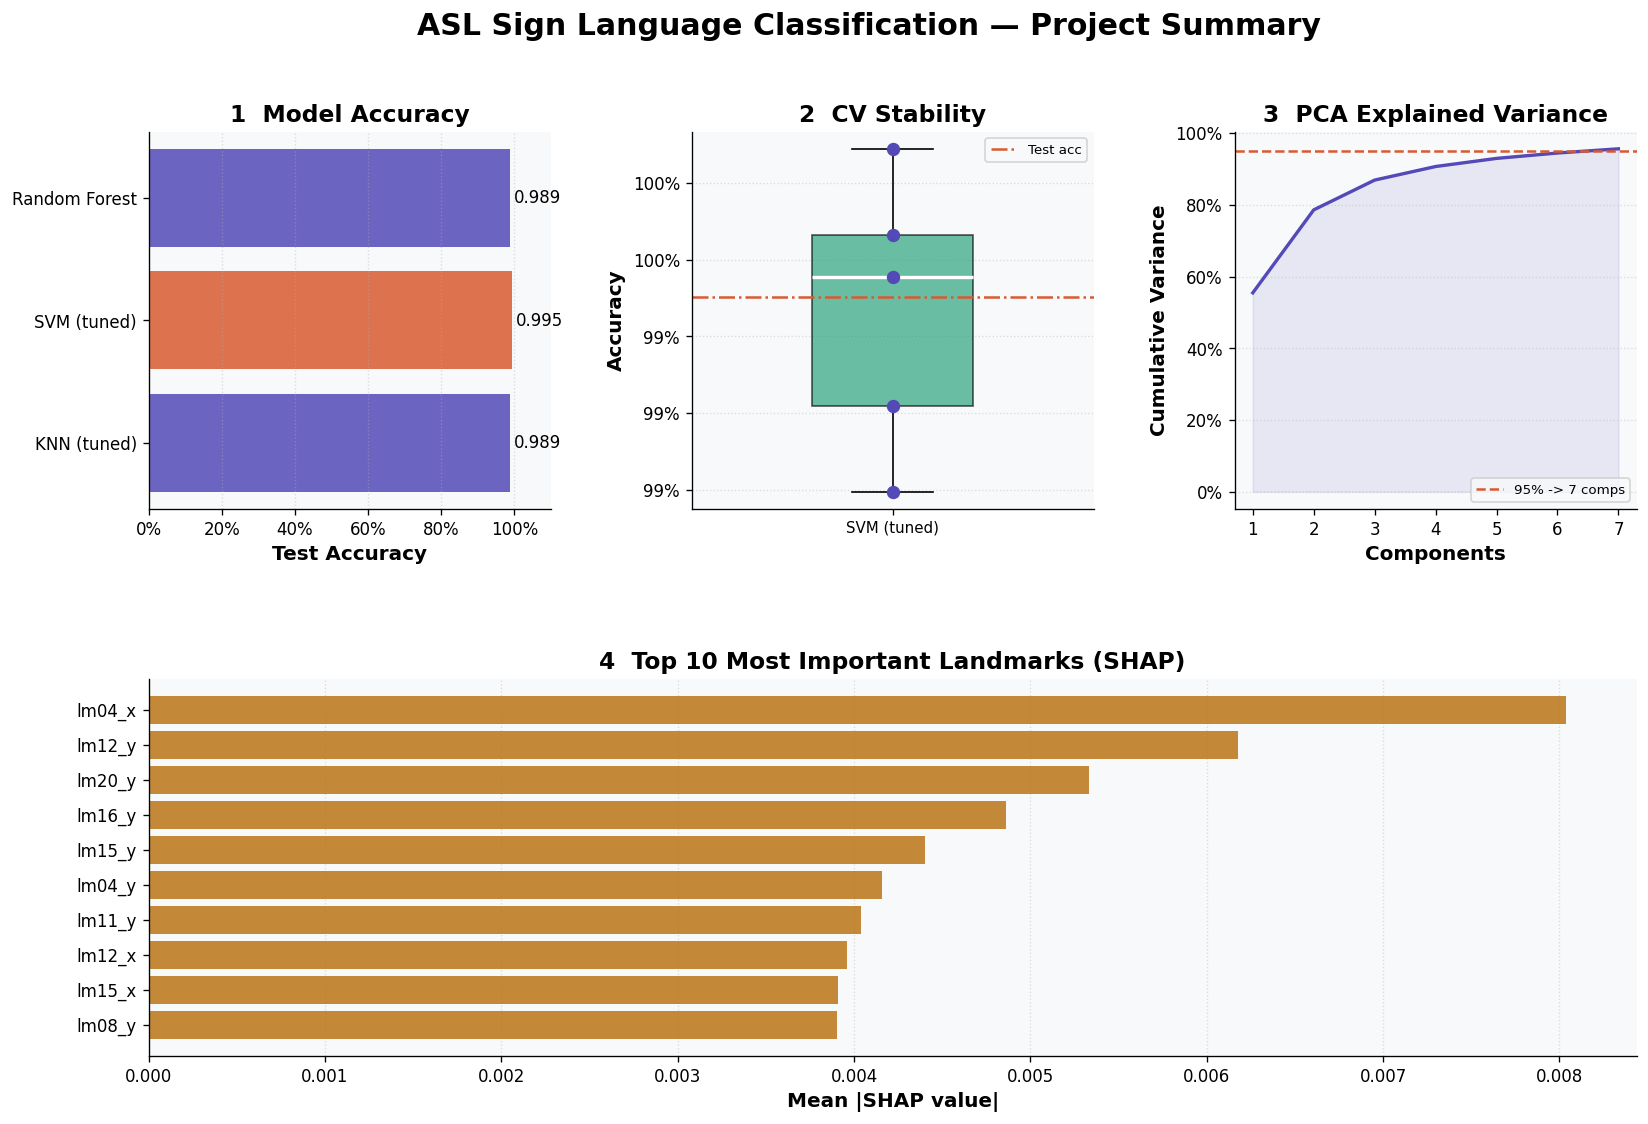

Dashboard saved as summary_dashboard.png


In [ ]:
# ─── Cell 23: Summary Dashboard — Full-Page Multi-Panel Figure ───────────────
# PURPOSE:
#   Produce a polished single-page summary combining the four key results
#   into one cohesive, presentation-ready figure.
#
# LAYOUT (GridSpec 3 rows x 3 cols):
#   Row 0, Cols 0-2 : Three panels side by side
#     Panel 1: Model accuracy bar chart
#     Panel 2: Cross-validation box plot
#     Panel 3: PCA cumulative variance
#   Row 1-2, all cols: SHAP top-20 importance (spans full width)
#
# figsize=(16, 10): enough canvas for all panels to be readable without crowding.
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib import gridspec

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
fig.suptitle(
    'ASL Sign Language Classification — Project Summary',
    fontsize=18, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Model accuracy ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
p_accs = [v['acc'] for v in results.values()]
ax1.barh(
    list(results.keys()), p_accs,
    color=[PALETTE[2] if a == max(p_accs) else PALETTE[0] for a in p_accs],
    alpha=0.85
)
ax1.set_xlim(0, 1.1)
ax1.set_title('1  Model Accuracy', fontweight='bold')
ax1.set_xlabel('Test Accuracy')
for i, (k, v) in enumerate(results.items()):
    ax1.text(v['acc'] + 0.01, i, f"{v['acc']:.3f}", va='center', fontsize=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.xaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 2: CV box plot ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.boxplot(
    cv_scores, patch_artist=True, widths=0.4,
    boxprops=dict(facecolor=PALETTE[1], alpha=0.65),
    medianprops=dict(color='white', linewidth=2)
)
for score in cv_scores:
    ax2.plot(1, score, 'o', color=PALETTE[0], markersize=7, zorder=5)
ax2.axhline(
    results[best_name]['acc'], color=PALETTE[2],
    linestyle='-.', linewidth=1.5, label='Test acc'
)
ax2.set_xticks([1])
ax2.set_xticklabels([best_name], fontsize=9)
ax2.set_title('2  CV Stability', fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.yaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 3: PCA variance ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cum_var_dash = np.cumsum(pca_full.explained_variance_ratio_)
ax3.plot(range(1, len(cum_var_dash) + 1), cum_var_dash, color=PALETTE[0], linewidth=2)
ax3.fill_between(range(1, len(cum_var_dash) + 1), cum_var_dash, alpha=0.1, color=PALETTE[0])
ax3.axhline(0.95, color=PALETTE[2], linestyle='--', linewidth=1.5,
            label=f'95% -> {pca_full.n_components_} comps')
ax3.set_title('3  PCA Explained Variance', fontweight='bold')
ax3.set_xlabel('Components')
ax3.set_ylabel('Cumulative Variance')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax3.legend(fontsize=8, loc='lower right')
ax3.yaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 4: SHAP top-10 (full width bottom) ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
top10 = shap_df.head(10)
ax4.barh(
    top10['feature'][::-1], top10['mean_shap'][::-1],
    color=PALETTE[3], alpha=0.85
)
ax4.set_xlabel('Mean |SHAP value|')
ax4.set_title('4  Top 10 Most Important Landmarks (SHAP)', fontweight='bold')
ax4.xaxis.grid(True, linestyle=':', alpha=0.4)
ax4.set_axisbelow(True)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as summary_dashboard.png')


---
## Project Checklist

| Component | Description | Status |
|---|---|---|
| Package installation | All dependencies installed fresh | Done |
| Kaggle download | ASL Alphabet dataset via API | Done |
| EDA class distribution | Bar chart — balance check | Done |
| EDA image grid | 4x4 thumbnail grid | Done |
| MediaPipe setup | HandLandmarker Tasks API | Done |
| Feature extraction | 63-dim landmark vectors + disk cache | Done |
| Label encoding | String -> integer targets | Done |
| Train/test split | Stratified 80/20 | Done |
| StandardScaler | Z-score normalisation | Done |
| SMOTE | Synthetic minority over-sampling | Done |
| PCA scree | Cumulative variance chart | Done |
| PCA 2D scatter | Feature space visualisation | Done |
| KNN GridSearchCV | Hyper-parameter tuning | Done |
| SVM GridSearchCV | Hyper-parameter tuning | Done |
| Random Forest | 300-tree benchmark | Done |
| Accuracy comparison | Horizontal bar chart | Done |
| CV stability | Box plot + fold dots | Done |
| Confusion matrix | 29x29 heatmap | Done |
| SHAP computation | TreeExplainer on RF | Done |
| SHAP importance chart | Top 20 features | Done |
| Model serialisation | joblib .pkl + JSON | Done |
| predict_sign() | Production inference helper | Done |
| Summary dashboard | 4-panel full-page figure | Done |

---

### Suggested Next Steps

| Idea | Benefit |
|---|---|
| **Real-time webcam demo** | `cv2.VideoCapture(0)` + `predict_sign()` in a loop |
| **LSTM for dynamic signs** | Extend to frame sequences for full words |
| **Signer-independent split** | Train on signers A-D, test on signer E |
| **Feature pruning** | Keep top-K SHAP features and measure speed vs accuracy |
| **CNN baseline** | Compare raw-pixel CNN to the MediaPipe approach |
